# Level 2 - Task 2: Time Series Analysis

## Internship Project - Codveda Technologies

### Objective
The objective of this project is to analyze stock price data over time, identify trends, apply moving average smoothing, and visualize stock price patterns using Python.

## Step 1: Importing Required Libraries

In this step, I imported the required Python libraries for data analysis, time series processing, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Loading the Dataset

The stock price dataset is loaded using pandas. The first five rows are displayed to understand the structure of the data.

In [3]:
df = pd.read_csv('/content/2) Stock Prices Data Set.csv')
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


## Step 3: Understanding the Dataset

This step helps understand the number of rows and columns, column names, data types, and general structure of the dataset.


In [4]:
df.shape

(497472, 7)

In [5]:
df.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


## Step 4: Converting Date Column

The date column is converted into datetime format so that Python can recognize it as a time-based variable.

In [8]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497464 non-null  float64       
 4   low     497464 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


## Step 5: Checking Missing Values

Missing values are checked because they can affect time series analysis and visualizations.

In [9]:
df.isnull().sum()

,0
symbol,0
date,0
open,11
high,8
low,8
close,0
volume,0


## Step 5.1: Handling Missing Values

The missing numerical values are replaced with the median value of each column to improve data consistency and avoid issues during analysis.

In [10]:
df['open'] = df['open'].fillna(df['open'].median())

df['high'] = df['high'].fillna(df['high'].median())

df['low'] = df['low'].fillna(df['low'].median())

df.isnull().sum()

,0
symbol,0
date,0
open,0
high,0
low,0
close,0
volume,0


## Step 6: Selecting One Stock Symbol

The dataset contains multiple stock symbols. For time series analysis, I selected one company stock to analyze over time.

In [11]:
df['symbol'].unique()[:20]

array(['AAL', 'AAPL', 'AAP', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI',
       'ADM', 'ADP', 'ADSK', 'ADS', 'AEE', 'AEP', 'AES', 'AET', 'AFL',
       'AGN', 'AIG'], dtype=object)

In [12]:
stock = df[df['symbol'] == 'AAPL']
stock.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


## Step 7: Sorting Data by Date

The selected stock data is sorted by date to make sure the time series is in correct chronological order.

In [13]:
stock = stock.sort_values('date')
stock.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


## Step 8: Plotting Closing Price Over Time

The closing price is plotted over time to identify general stock price trends.

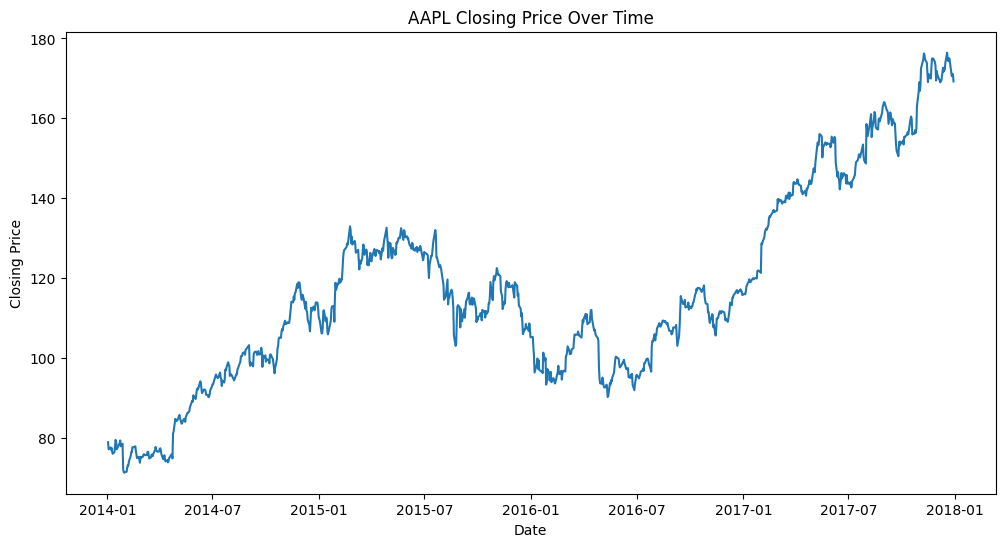

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(stock['date'], stock['close'])
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("AAPL Closing Price Over Time")
plt.show()

## Step 9: Moving Average Smoothing

A moving average is calculated to smooth short-term price fluctuations and highlight the overall trend.

In [16]:
stock["MA_30"] = stock['close'].rolling(window=300).mean()
stock.head()

,symbol,date,open,high,low,close,volume,MA_30
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,NaN
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870,NaN
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151,NaN
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766,NaN
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685,NaN


## Step 10: Closing Price with Moving Average

The original closing price and the 30-day moving average are plotted together to compare daily price changes with the overall trend.


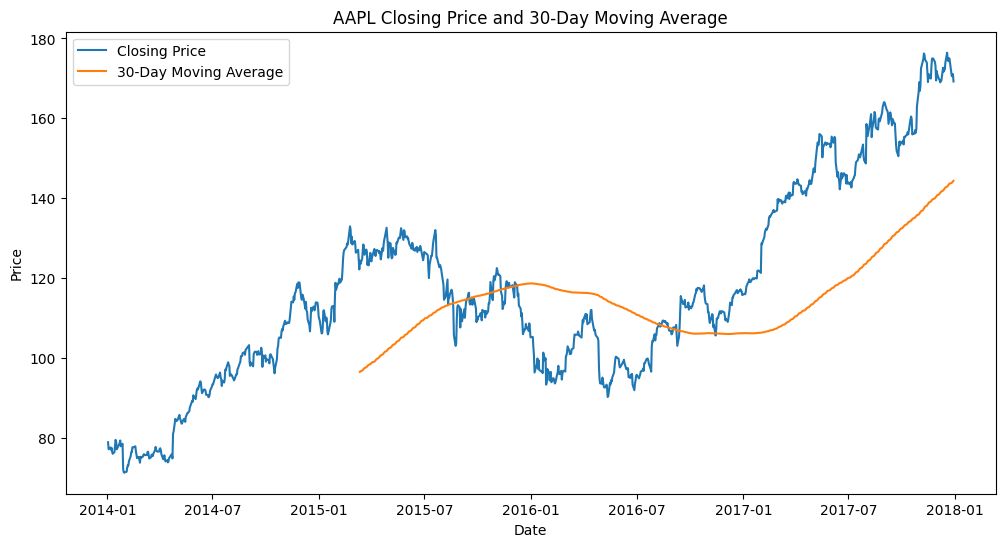

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(stock['date'], stock['close'], label='Closing Price')
plt.plot(stock['date'], stock['MA_30'], label='30-Day Moving Average')

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("AAPL Closing Price and 30-Day Moving Average")
plt.legend()
plt.show()

## Step 11: Monthly Average Closing Price

The data is grouped by month to analyze the average closing price for each month.

In [19]:
stock_monthly = stock.set_index('date').resample('M')['close'].mean()
stock_monthly.head()

/tmp/ipykernel_12899/1650047594.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stock_monthly = stock.set_index('date').resample('M')['close'].mean()


,close
date,
2014-01-31,76.777876
2014-02-28,75.225637
2014-03-31,76.173400
2014-04-30,77.296243
2014-05-31,86.170752


## Step 12: Visualizing Monthly Average Price

The monthly average closing price is plotted to show a clearer long-term stock price trend.

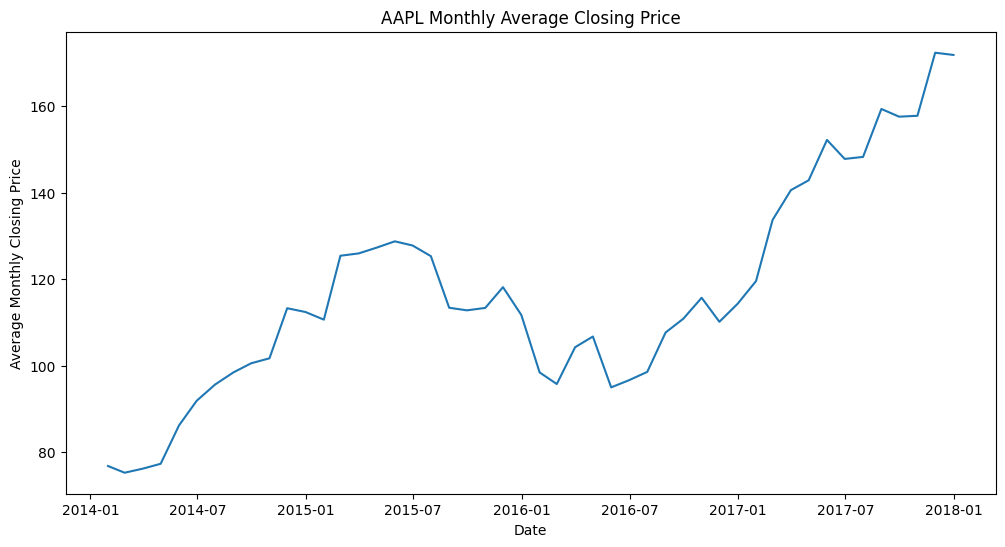

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(stock_monthly.index, stock_monthly.values)
plt.xlabel("Date")
plt.ylabel("Average Monthly Closing Price")
plt.title("AAPL Monthly Average Closing Price")
plt.show()

## Step 13: Trading Volume Over Time

Trading volume is plotted to understand how the number of traded shares changed over time.

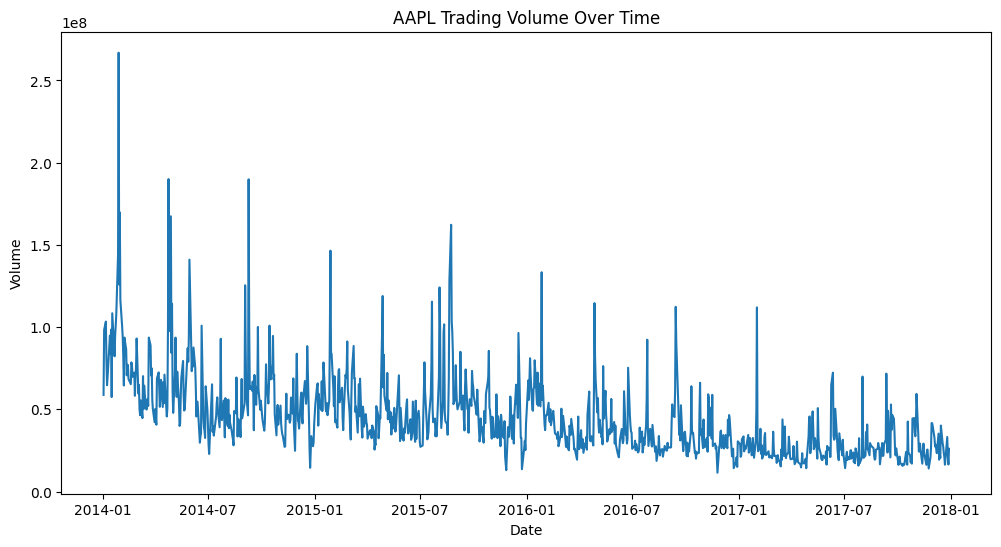

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(stock['date'], stock['volume'])
plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("AAPL Trading Volume Over Time")
plt.show()

## Step 14: Daily Price Change

Daily price change is calculated to understand how much the stock price changed from one day to the next.


In [22]:
stock['Daily_Change'] = stock['close'].diff()
stock[['date','close', 'Daily_Change']].head()

,date,close,Daily_Change
1,2014-01-02,79.0185,NaN
484,2014-01-03,77.2828,-1.7357
967,2014-01-06,77.7042,0.4214
1450,2014-01-07,77.1481,-0.5561
1933,2014-01-08,77.6371,0.4890


## Step 15: Visualizing Daily Price Change

Daily price changes are visualized to identify volatility in the stock price.

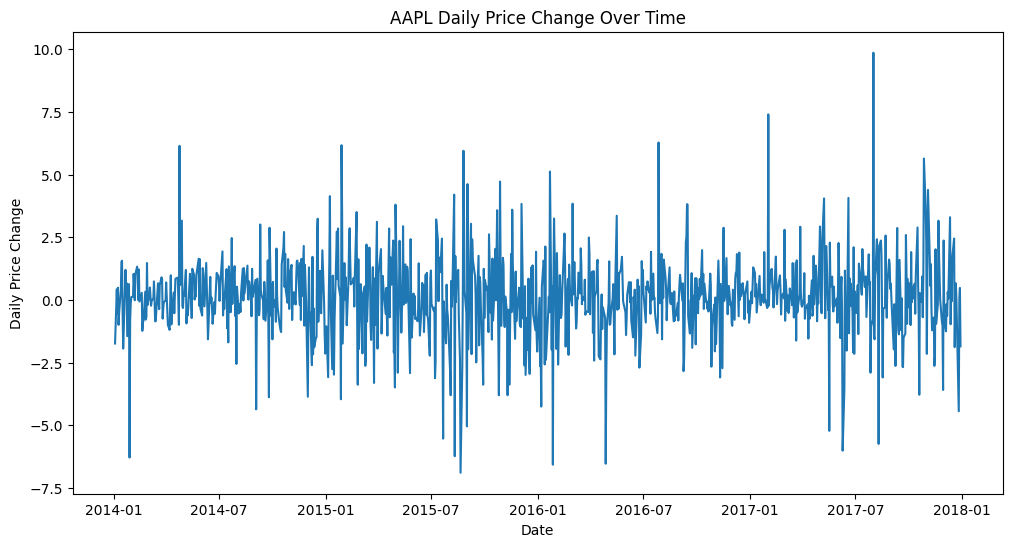

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(stock['date'], stock['Daily_Change'])
plt.xlabel("Date")
plt.ylabel("Daily Price Change")
plt.title("AAPL Daily Price Change Over Time")
plt.show()

# Conclusion

In this Level 2 time series analysis project, I analyzed stock price data using Python.

First, I loaded the stock dataset and converted the date column into datetime format. Since the dataset contained multiple stock symbols, I selected AAPL stock for analysis.

I visualized the closing price over time to identify general trends. Then, I applied a 30-day moving average to smooth short-term fluctuations and better understand the overall price movement.

I also calculated monthly average closing prices to observe long-term trends and analyzed trading volume over time. Finally, I calculated daily price changes to understand stock price volatility.

Overall, this project demonstrated how time series analysis can be used to study financial data, identify trends, and understand price movement patterns over time.